# Module 3: Crystal Graph Convolutional Neural Networks

The aim of this tutorial is to analyze the data processing methods used in the code developed by Tian Xie and Jeffrey C. Grossman, which is available in the repository [CGCNN](https://github.com/txie-93/cgcnn). This code is based on their research article titled [Crystal Graph Convolutional Neural Networks for an Accurate and Interpretable Prediction of Material Properties](https://arxiv.org/pdf/1710.10324).

This tutorial includes the following sections:
1. Using pretrained CGCNN model with predefined features to predict formation enegrgy per atom.
2. Training simple single convovoluon neural network with custom feature extraction
3. And finally you homework where you will train GCNNN using original code (in separate notebook)

# Setup
**step0** Let's start with installation of necessary packages
Here's a brief explanation of the following code for installing packages. It is used for convenience when working in Colab - packages are installed once and saved in the current session! If you are experimenting in a local environment, comment out the code below and install the necessary packages manually.

In [ ]:
%%capture
try:
    import pymatgen
except:
    !pip install pymatgen  # Library for materials science analysis
    !pip install ase  # Toolkit for atomistic simulations|
    !pip install sqlalchemy  # SQL toolkit and ORM for database interaction
    !pip install mp-api  # Client for accessing Materials Project API
    !pip install --no-deps mendeleev  # Access to periodic table data
    !pip install pandas  # Data manipulation and analysis library
    #!pip install torch  # Machine learning library for deep learning
    #!pip install requests  # Simplifies HTTP requests
    #!pip install -U scikit-learn  # Machine learning algorithms library

Let's import some very necesary packages

In [ ]:
import os
import random
import mendeleev
import numpy as np
import pymatgen
import torch  # The torch package contains data structures for multi-dimensional tensors and defines mathematical operations over these tensors.
import torch.nn as nn  # Subpackage of building blocks for all neural network modules.
import torch.optim as optim  # Subpackage implementing various optimization algorithms
from torch.utils.data import DataLoader, Dataset
import warnings

In [ ]:
# make style plots
import matplotlib.pyplot as plt # graphs plotting
plt.rcParams.update({           # matplotlib parameters fine tuning
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "savefig.dpi": 300,
    "figure.figsize": (4, 3),
    "figure.dpi": 150,
    "axes.grid": True,
    'legend.loc': 'best',
    "grid.linestyle": "--",
    "grid.alpha": 0.6})

# Code to run the pretrain model
We will use some parts from orignal repository to simplify perception and redability of this tutorial. All necessary codes to undestand general concepts will be implemented in this notebook.

In [ ]:
# download original codes and export necessary modules, mainly used in your homework
if os.path.exists('model.py') == 0:
    !wget https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/cgcnn/model.py
if os.path.exists('data.py') == 0:
    !wget https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/cgcnn/data.py
if os.path.exists('predict.py') == 0:
    !wget https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/predict.py

from model import ConvLayer,  CrystalGraphConvNet
from data import collate_pool, GaussianDistance

--2025-06-27 10:32:11--  https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/cgcnn/model.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6655 (6.5K) [text/plain]
Saving to: ‘model.py’

model.py            100%[===================>]   6.50K  --.-KB/s    in 0s      

2025-06-27 10:32:11 (83.1 MB/s) - ‘model.py’ saved [6655/6655]

--2025-06-27 10:32:11--  https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/cgcnn/data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12708 (12K) [text/plain]
Saving to: 

In [ ]:
# the utility function to fix all seed to make code more reproducible
def set_seed(seed=42):
    # Python's built-in random module
    random.seed(seed)

    # Numpy's random module
    np.random.seed(seed)

    # PyTorch seed for CPU
    torch.manual_seed(seed)

    # PyTorch seed for all GPU devices (if using CUDA)
    torch.cuda.manual_seed_all(seed)

    # Make sure to disable CuDNN's non-deterministic optimizations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)

#PART 0. Using pre-trainding model
A. In this section we will see how to use pretrained CGCNN model, on predefined features
- We will load CsCl structure using materials project api
- We will load predefined feature extractor (by Tian Xie).
- We will load pretrained model
- Prepate data and make prediction

#### Attention this is illustrative example, it would be better to use classes from later sections, that used for real training

Step01. Let's load CsCL structure using material project api

In [ ]:

from mp_api.client import MPRester

# lets load simple CsCl as in lectures
formula = "CsCl"
API_KEY = "" # you need you own key here

with MPRester(API_KEY) as mpr:
    # Query materials by formula (e.g., CsCl)
    results = mpr.materials.search(formula=formula)

    # Optionally, get the structure of the first match
    if results:
        print(f"Number of mateched Structures: {len(results)}")
        crystal = results[0].structure
        print(crystal)

# Given material id lets download all its properties
mp_id = results[0].material_id
with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        material_ids=[mp_id],
    )
crystal = docs[0].structure

Retrieving MaterialsDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

Number of mateched Structures: 2
Full Formula (Cs1 Cl1)
Reduced Formula: CsCl
abc   :   4.143698   4.143698   4.143698
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c    magmom
---  ----  ----  ----  ----  --------
  0  Cs    -0    -0    -0           0
  1  Cl     0.5   0.5   0.5         0


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

## Note about feature encoding

Step02. In the original work, the following features are utilized:  
- Group number  
- Period number  
- Electronegativity  
- Covalent radius  
- Valence electrons  
- First ionization energy  
- Electron affinity  
- Block  
- Atomic volume  



Additionally, these features are one-hot encoded for further processing. One-hot encoding is a technique used to convert categorical variables into a binary matrix representation, where each category is represented by a vector with a single '1' (indicating the presence of that category) and '0's elsewhere. For instance, if for a given atom we have period 2 (for Li), it will be represented by the vector [0, 1, 0, 0, 0, ...].  

In the case of continuous variables, the range of values is split into equal intervals (e.g., 0-10, 10-20, 20-30), and each interval is treated as a category. For example, let’s illustrate this approach for both categorical variables (period) and continuous variables (covalent radius) for the three elements: H, Li, and Na.

| **Element** | **Period1** | **Period2** | **Period3** |
|-----------|---------|-----------|----------|
| H       | 1       | 0         | 0        |
| Li     | 0       | 1         | 0        |
| Na      | 0       | 0         | 1        |

| Element | Covalent Radius | R1 (31-100) | R2 (101-150) | R3 (150+) |  
|---------|-----------------|-------------|--------------|-----------|  
| H       | 31              | 1           | 0            | 0         |  
| LI      | 128             | 0           | 1            | 0         |  
| NA      | 166             | 0           | 0            | 1         |  

**step03.** Let's download pre-defined features

In [ ]:
import requests
import json

# URL pointing to the JSON file containing atom feature data exaty as they in txie-93 paper
atom_init_url = "https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/data/sample-regression/atom_init.json"

# Send an HTTP GET request to the specified URL to retrieve the data
response = requests.get(atom_init_url)

# Check if the request was successful
# If the status code indicates an error (e.g., 404 or 500), raise an HTTPError
response.raise_for_status()

# Parse the JSON content of the response into a Python dictionary
# This dictionary will map atomic numbers or symbols to their corresponding feature vectors
atom_features_table = json.loads(response.text)

In [ ]:
for a in crystal:
    number = a.specie.number
    features = atom_features_table[str(number)]
    print('atom:',a.specie.symbol, 'has period', np.argmax(features[:19]), 'and corresponding binary features', features[:19])


For edge features, the interatomic distance is used, but in a unique way. A Gaussian basis is applied to expand the distance values.  

The Gaussian filter is defined as:  

$$
e^{-\left(\frac{(d-\mu_k)^2}{\sigma^2}\right)}
$$  

Here, $d$ represents the interatomic distance, $\mu_k$ (also referred to as the filter) is equally spaced with length $k$ within the interval $(0, r_{cut})$, and $\sigma = k$ denotes the step size of the distances.

The hyperparameter $\sigma$ controls the granularity of the representation and determines the precision of the filter. In the paper, $\sigma$ is set to $0.2 \, \text{Å}$.

Intution is that it works as a smootihg.
In other words The Gaussian filter transforms a single distance value (e.g., 5 Å) into a smooth, continuous vector representation. Instead of using the raw distance (a scalar value of 5), we generate a vector where the distance is "smoothed" across multiple bins, with the highest activation centered around the true distance.  

In [ ]:
distances = np.array([5])
filter = GaussianDistance(0.1,10,1)
filtered = filter.expand(distances)

In [ ]:
filtered.shape

(1, 11)

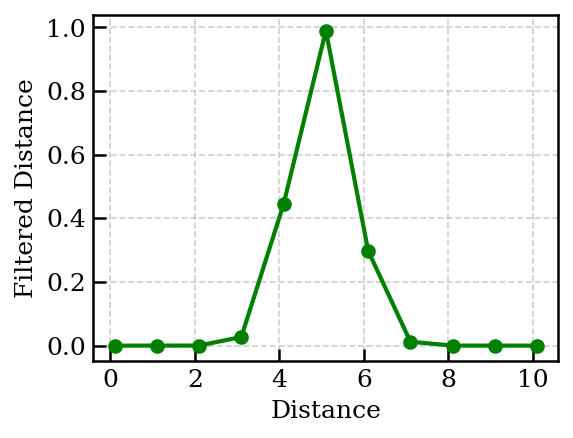

In [ ]:
import matplotlib.pyplot as plt
plt.plot(filter.filter,filtered[0],color='green',marker='o')
plt.ylabel("Filtered Distance")
plt.xlabel("Distance")
plt.show()

In [ ]:
filtered[0]

array([3.73757133e-11, 2.47959602e-07, 2.22629857e-04, 2.70518469e-02,
       4.44858066e-01, 9.90049834e-01, 2.98197279e-01, 1.21551783e-02,
       6.70548243e-05, 5.00621802e-08, 5.05825274e-12])

## Building CsCl csytal graph

**Step04**. Now we have individual features of atoms, but we need a crystal graph to work with CGCNN. As discussed in the lectures, we operate in an infinite 3D space, and our nodes are sites, not individual atoms! This means that the neighbor of the current atom is not an individual atom but a set of periodic neighbors derived from atomic sites. The good news is that pymatgen can handle all symmetries for us. We don’t need to use translations and other transformations as described in the lectures.

In [ ]:
# Set the radius for neighbor search in Angstroms
neighbor_search_radius = 8
# Maximum number of neighbors to consider for each atom
maximum_number_of_neighbors = 12

# Initialize GaussianDistance with specified parameters
gaussian_distance_function = GaussianDistance(dmin=0, dmax=neighbor_search_radius, step=0.2)

# Get all neighbors within the specified radius, including their indices
all_neighbors = crystal.get_all_neighbors(neighbor_search_radius, include_index=True)

In [ ]:
all_neighbors[0][:3]

[PeriodicNeighbor: Cl (-2.072, -2.072, -2.072) [-0.5, -0.5, -0.5],
 PeriodicNeighbor: Cs (-4.144, -4.144, -4.144) [-1.0, -1.0, -1.0],
 PeriodicNeighbor: Cl (-2.072, -2.072, -6.216) [-0.5, -0.5, -1.5]]

**Step05.** Rembeber to represent a graph we need a set of nodes, edges and correspoinding features! Let's make them. The next code generates features for atoms and their neighbors to construct a crystal graph. First, a matrix of atom features is created based on their atomic numbers. Then, for each atom, the neighbors are sorted by distance. Next, the indices of the neighbors and their distances are extracted, which will be used as edge features in the graph.

In [ ]:
# Create atom features using a predefined table based on atomic numbers
atom_feature_matrix = np.vstack([atom_features_table[str(atom.specie.number)]
                                 for atom in crystal])

# Sort neighbors by distance for each atom
all_neighbors_sorted = [sorted(neighbors, key=lambda x: x[1]) for neighbors in all_neighbors]

# Print the number of neighbor lists (should match the number of atoms)
print(len(all_neighbors_sorted))

# Initialize lists to store neighbor (edge) feature  indices and features
neighbor_feature_indices, distance_features = [], []

# Iterate over each atom's neighbors
for neighbors in all_neighbors_sorted:
    # each neighbors structure (site, distance, index) let's peak only 12
    neighbors = neighbors[::][:maximum_number_of_neighbors]
    neighbor_feature_indices.append([n[2] for n in neighbors])
    distance_features.append([n[1] for n in neighbors])



**Step06.** Lets' convert data to torch.Tensor format

In [ ]:
# Convert neighbor feature indices and features to numpy arrays
neighbor_feature_indices = np.array(neighbor_feature_indices)
distance_features = np.array(distance_features)

# Expand neighbor features using GaussianDistance
distance_features = gaussian_distance_function.expand(distance_features)

# Convert atom features and neighbor features to PyTorch tensors
atom_feature_tensor = torch.Tensor(atom_feature_matrix)
distance_feature_tensor = torch.Tensor(distance_features)
neighbor_feature_indices_tensor = torch.LongTensor(neighbor_feature_indices)

**Step07.**Now we can create a single example dataset before passing it into the model. Collate_pool function will be explained later when we will train own neural network.

In [ ]:
# Create a a single example  dataset entry with features and target
dataset_entry = [[(atom_feature_tensor.to(device), distance_feature_tensor.to(device), neighbor_feature_indices_tensor.to(device)),
                  torch.tensor(0).to(device), mp_id]]
# Use collate_pool to prepare a batch from the dataset
batch = collate_pool([dataset_entry[0]])

**Step08.** Now Let's prepare a pretrained model, downloaded directly from orignal repository!

In [ ]:
from types import SimpleNamespace
# download pretrained model
model_url = "https://github.com/txie-93/cgcnn/raw/refs/heads/master/pre-trained/formation-energy-per-atom.pth.tar"
!wget $model_url -O model.pth.tar
# load it into pytorch
checkpoint = torch.load('model.pth.tar', map_location="cpu", weights_only=False)
args = checkpoint['args']
# we also need nornmalizer, since nn usually works with normalized features
normalizer = SimpleNamespace(**checkpoint['normalizer']) # extrating mean and std for target property

**Step09.** Now we can construct the model using args from checkpoint

In [ ]:
# construct model and load checkpoint
structures, _, _ = dataset_entry[0]
orig_atom_fea_len = structures[0].shape[-1]
nbr_fea_len = structures[1].shape[-1]

classification=True if args['task'] == 'classification' else False
model = CrystalGraphConvNet(orig_atom_fea_len, nbr_fea_len,
                            atom_fea_len=args['atom_fea_len'],
                            n_conv=args['n_conv'],
                            h_fea_len=args['h_fea_len'],
                            n_h=args['n_h'],
                            classification=classification).to(device)
model.load_state_dict(checkpoint['state_dict']);


**Step10.** Let's make a prediction of formation energy per atom!

In [ ]:
# Assuming `model` is a pre-trained model and `batch` is a batch of data prepared for input

# Pass the batch data through the model to get the outputs
# The model takes multiple inputs, which are unpacked from the batch
model.eval()
outputs = model(batch[0][0], batch[0][1], batch[0][2], batch[0][3])

# Denormalize the model's output to get the predicted value
# The output is assumed to be normalized, so we reverse the normalization
# using the standard deviation and mean from the normalizer
predicted_value = (outputs[0] * normalizer.std + normalizer.mean).item()

**Step11.** Now we can create a fancy table to see the result

In [ ]:
import pandas as pd

# Retrieve the true value of the property being predicted
# This is typically stored in the dataset, here accessed via `docs`
true_value = docs[0].formation_energy_per_atom

# Create a DataFrame to store the predicted and true values
# The DataFrame is initialized with a list containing the predicted and true values
df = pd.DataFrame([predicted_value, true_value]).T

# Set the column names of the DataFrame
df.columns = "predicted_value,true_value".split(',')

# Set the index of the DataFrame to the chemical formula of the compound
# This assumes `formula` is a string representing the chemical formula
df.index = [formula]

# Extract the property name from the model URL
# The property name is assumed to be part of the model file name
property_name = model_url.split("/")[-1].replace(".pth.tar", "")

# Set the index name of the DataFrame to the property name
# This provides context for what the index represents
df.index.name = property_name

# Computing absolute error
df['abosulute_error'] = abs(df['true_value'] - df['predicted_value'])

In [ ]:
df

# Part 1. Trainining simplified model

**Step12.**
## Train almost single layer model

Before diving into training your own CGCNN model (which will be your homework), let's conduct a simple experiment. We'll create a basic one-layer model to understand how convolution and pooling work in the context of GCNN and to determine if a given crystal is a metal (🤘) or not. The authors propose two straightforward operations for convolution and pooling:

### Convolution Operation

$$
{v}_i^{(t+1)} = g\left[ \left( \sum_{j, k} {{v}_j^{} \bigoplus {u}_{(i, j)_k}} \right) {W}_c^{} + {v}_i^{} {W}_s^{} + {b}^{} \right]
$$

### Pooling Operation

$$
{v_c} = \sum_{i} {\tilde{v}}_i^{}
$$

Let's implement these operations and train the model!


### Breaking Down the Formulas

#### Convolution

Consider a system with several atoms, each having a maximum of 3 neighbors. Let's denote the attribute of atom 0 as $v0$. Suppose it has 3 neighbors with attributes $v1, v2, v3$. Similarly, denote the corresponding edge attributes as $u{(0,1)}, u{(0,2)}, u{(0,3)}$. For atoms 0 and 1, the resulting list of matrices will look as follows:
    
$$
\sum_{j, k}  \left(  {{v}_j^{} \bigoplus {u}_{(i, j)_k}} \right) =
\sum
\begin{align*}
    \left(
    \begin{bmatrix}
    v_0& v_1 & u_{(0,1)} \\
    v_0& v_2 & u_{(0,2)} \\
    v_0& v_3 & u_{(0,3)} \\
    \end{bmatrix}
    ,
    \begin{bmatrix}
    v_1& v_3 & u_{(1,3)} \\
    v_1& v_4 & u_{(1,4)} \\
    v_1& v_5 & u_{(1,5)} \\
    \end{bmatrix} \right)
\end{align*}
$$

Further we sum the matrices and multiply it by some weight (in matrix multiplication sense):
$$
\left( \sum_{j, k} {{v}_j^{} \bigoplus {u}_{(i, j)_k}} \right) {W}_c^{} =
\begin{align*}
    \left(
    \begin{bmatrix}
    v_0& v_1 & u_{(0,1)} \\
    v_0& v_2 & u_{(0,2)} \\
    v_0& v_3 & u_{(0,3)} \\
    \end{bmatrix}
    +
    \begin{bmatrix}
    v_1& v_3 & u_{(1,3)} \\
    v_1& v_4 & u_{(1,4)} \\
    v_1& v_5 & u_{(1,5)} \\
    \end{bmatrix} \right)
    \begin{bmatrix}
    w_1 & w_2 & w_7 \\
    w_2 & w_4 & w_8 \\
    w_3 & w_6 & w_9 \\
    \end{bmatrix}
    =
    \begin{bmatrix}
    w1(v_0 + v1)& w2(v_1+v_3) & w3(u_{(0,1)} + u_{(1,3)}) \\
    w4(v_0 + v1)& w5(v_2+v_4) & w6(u_{(0,2)} + u_{(1,3)}) \\
    w7(v_0 + v1)& w8(v_3+v_5) & w9(u_{(0,3)} + u_{(1,3)}) \\
    \end{bmatrix}
\end{align*}
$$

The first part of the formula calculates a weighted sum not just of features, but of the sum of all neighbor sites for a given atom.

#### Second Part

The second part, $${v}_i^{} {W}s^{} + {b}^{}$$, applies a weight to the current atom's feature vector, and $g$ is a nonlinear function, such as softplus.

Now, let's implement these operations and train the model!

### Custom Feature Extraction
**Step13.**
In this tutorial, in contrast with original work we will explore a Python class designed to generate feature vectors for chemical elements based on their atomic symbols. This class is **called** AtomFeatureExtractor.  The class extracts atomic features (e.g., group ID, period, covalent radius) for a given element and optionally encodes categorical features using one-hot encoding.

In [ ]:
basic_features = ["group_id", "period", "covalent_radius_cordero"]
extended_features = basic_features## + ["electronegativity"]

In [ ]:
import mendeleev
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from mendeleev.fetch import fetch_table

class AtomFeatureExtractor:
    def __init__(self, onehot=True, max_categories=10, feature_name_list=None):
        """
        Initialize the AtomFeatureExtractor with the given parameters.

        Parameters
        ----------
        onehot : bool, optional
            If True, categorical features are one-hot encoded. Default is True.
        max_categories : int, optional
            The maximum number of categories for one-hot encoding. Default is 10.
        feature_name_list : list of str, optional
            List of attribute names to extract for the element. Default is ["group_id", "period", "covalent_radius_cordero"].
        """
        self.onehot = onehot
        self.ptable = fetch_table("elements")
        self.max_categories = max_categories
        self.feature_name_list = feature_name_list or ["group_id", "period", "covalent_radius_cordero"]
        self.encoders = self._initialize_encoders()

    def _initialize_encoders(self):
        """
        Initialize and fit encoders for each attribute in the feature list.

        Returns
        -------
        dict
            A dictionary of fitted encoders for each attribute.
        """
        encoders = {}
        if self.onehot:
            for attribute_name in self.feature_name_list:
                all_attribute_values = self._get_all_attribute_values(attribute_name)
                encoder = OneHotEncoder(handle_unknown='ignore', max_categories=self.max_categories)
                encoder.fit(all_attribute_values[None].T)
                encoders[attribute_name] = encoder
        return encoders

    def _get_feature(self, symbol, attribute_name):
        """
        Retrieve the feature for the given attribute name.

        Parameters
        ----------
        symbol : str
            The atomic symbol of the element (e.g., 'H', 'C', 'O').
        attribute_name : str
            The name of the attribute to retrieve.

        Returns
        -------
        feature : float or numpy.ndarray
            The feature value or one-hot encoded feature vector.
        """
        feature = None
        if attribute_name in self.ptable.columns:
            feature = self.ptable[self.ptable.symbol==symbol][attribute_name].values[0]

        if feature is None: # it means that this feature is computable
            elem = mendeleev.element(symbol)
            feature = getattr(elem, attribute_name)
            feature = feature()

        if self.onehot:
            encoder = self.encoders.get(attribute_name)
            feature = encoder.transform(np.array([feature])[None])
            feature = np.array(feature.todense()).flatten()

        return feature

    def _get_all_attribute_values(self, attribute_name):
        """
        Retrieve all attribute values for one-hot encoding.

        Parameters
        ----------
        attribute_name : str
            The name of the attribute to retrieve values for.

        Returns
        -------
        numpy.ndarray
            Array of all attribute values.
        """
        if attribute_name == "electronegativity":
            min_value = 0.7
            max_value = 3.98
            return np.arange(min_value, max_value, self.max_categories)
        else:
            return np.array([a for a in mendeleev.get_attribute_for_all_elements(attribute_name) if a is not None])

    def extract_features(self, symbol):
        """
        Extract features for the element based on the specified attributes.

        Returns
        -------
        symbol : str
            The atomic symbol of the element (e.g., 'H', 'C', 'O').
        numpy.ndarray
            A concatenated feature vector for the element.
        """
        features = [self._get_feature(symbol, attr) for attr in self.feature_name_list]
        return np.concatenate(features) if self.onehot else np.array(features)

In [ ]:
extractor  = AtomFeatureExtractor(feature_name_list=extended_features, onehot=True)

In [ ]:
extractor.extract_features('Cu')

**Step14.**
### Dataset class

The next code defines a custom dataset class called MPData that loads and processes crystal structure data from the Materials Project (MP) database for our task. The class is designed to fetch crystal structures using material IDs (like "mp-19017") and extract useful features for training a model. Essentially, it replicates the steps we performed in previous part 0 in method called _get_item_.

In [ ]:
import functools

class MPData(Dataset):
    """
    The MPData dataset is a wrapper for a dataset where the crystal structures
    is quried via MPR api.

    Parameters
    ----------

    material_ids: list
        The list of material_ids, e.g. ["mp-19017", "mp-13", "mp-22526"]
    fields: list
        The list of physical mp properties we want to use as targets
    feature_name_list: list
        The list of physical mp properties we want to use as features

    max_num_nbr: int
        The maximum number of neighbors while constructing the crystal graph
    radius: float
        The cutoff radius for searching neighbors
    dmin: float
        The minimum distance for constructing GaussianDistance
    step: float
        The step size for constructing GaussianDistance
    device: torch.device or str,
        Th device where computations perfomed, eihter cuda or cpu
    onehot: bool
        Using onheot encoding for feature extraction
    random_seed: int
        Random seed for shuffling the dataset

    Returns
    -------

    atom_fea: torch.Tensor shape (n_i, atom_fea_len)
    nbr_fea: torch.Tensor shape (n_i, M, nbr_fea_len)
    nbr_fea_idx: torch.LongTensor shape (n_i, M)
    target: torch.Tensor shape (1, )
    mp_id: str or int
    """
    def __init__(self,
                 material_ids=["mp-19017", "mp-13", "mp-22526"],
                 fields=["structure", "is_metal", "is_magnetic",  "energy_per_atom", "material_id"],
                 feature_name_list=["group_id", "period", "covalent_radius_cordero"],
                 max_num_nbr=12, radius=8, dmin=0, step=0.2,
                 device='cpu',
                 onehot=True,
                 random_seed=2322123):
        self.max_num_nbr, self.radius = max_num_nbr, radius
        self.docs = None
        self.fields = fields
        self.rng = np.random.default_rng(random_seed)
        self.onehot = onehot
        # do some shuffle of material ids
        self.material_ids = list(material_ids)
        # a table with feature extractors per element
        self.extractor = AtomFeatureExtractor(feature_name_list=feature_name_list, onehot=self.onehot)
        with MPRester(API_KEY) as mpr:
            docs = mpr.materials.summary.search(
                material_ids=self.material_ids,
                fields=fields,
            )
            self.docs = docs
            # sort material ids, mpr is returning result asynchronously
            self.sorting_key = lambda x: int(str(x.material_id).split('mp-')[1])
            self.docs = sorted(self.docs, key = self.sorting_key)
            self.docs = self.rng.permutation(self.docs)
            self.material_ids = [str(d.material_id) for d in self.docs]
        assert self.docs is not None
        # all symbols presented in this dataset
        self.all_atoms_in_dataset = []
        for d in self.docs:
            for atom in d.structure:
                self.all_atoms_in_dataset.append(atom.specie.symbol)
        self.all_atoms_in_dataset = np.array(self.all_atoms_in_dataset)
        self.all_atoms_in_dataset  = np.unique(self.all_atoms_in_dataset)
        # we will cache all atom features here using
        self.atom_features_table = {}
        # extract features for all elements in periodic table
        for s in self.all_atoms_in_dataset:
            features = self.extractor.extract_features(s)
            self.atom_features_table[s] = features
        self.gdf = GaussianDistance(dmin=dmin, dmax=self.radius, step=step)
        self.device = device
        self.feature_name_list = feature_name_list


    def __len__(self):
        return len(self.docs)


    @functools.lru_cache(maxsize=None)  # Cache loaded structures
    def __getitem__(self, idx):
        crystal = self.docs[idx].structure
        target = self.docs[idx].is_metal
        atom_fea = np.vstack([self.atom_features_table[atom.specie.symbol]
                              for atom in crystal])

        atom_fea = torch.Tensor(atom_fea)
        all_nbrs = crystal.get_all_neighbors(self.radius, include_index=True)
        all_nbrs = [sorted(nbrs, key=lambda x: x[1]) for nbrs in all_nbrs]
        nbr_fea_idx, nbr_fea = [], []
        mp_id = self.material_ids[idx]
        for nbr in all_nbrs:
            if len(nbr) < self.max_num_nbr:
                warnings.warn('{} not find enough neighbors to build graph. '
                              'If it happens frequently, consider increase '
                              'radius.'.format(mp_id))
                nbr_fea_idx.append(list(map(lambda x: x[2], nbr)) +
                                   [0] * (self.max_num_nbr - len(nbr)))
                nbr_fea.append(list(map(lambda x: x[1], nbr)) +
                               [self.radius + 1.] * (self.max_num_nbr -
                                                     len(nbr)))
            else:
                nbr_fea_idx.append(list(map(lambda x: x[2],
                                            nbr[:self.max_num_nbr])))
                nbr_fea.append(list(map(lambda x: x[1],
                                        nbr[:self.max_num_nbr])))
        nbr_fea_idx, nbr_fea = np.array(nbr_fea_idx), np.array(nbr_fea)
        nbr_fea = self.gdf.expand(nbr_fea)
        atom_fea = torch.Tensor(atom_fea).to(self.device)
        nbr_fea = torch.Tensor(nbr_fea).to(self.device)
        nbr_fea_idx = torch.LongTensor(nbr_fea_idx).to(self.device)
        target = torch.Tensor([float(target)]).to(self.device)
        return (atom_fea, nbr_fea, nbr_fea_idx), target, mp_id

**Step15.**
Let's download material IDs used in original paper.

In [ ]:
# URL of the CSV file that contains some mp ids
url = "https://raw.githubusercontent.com/txie-93/cgcnn/refs/heads/master/data/material-data/mp-ids-3402.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(url,header=None)
df.columns = ['mp-ids']

# Display the first few rows of the DataFrame
print(df.head())

**Step16.** Let's visualize the class distribution (1 if the crystal is considered a metal, otherwise 0) using a histogram.

In [ ]:
# Set the device for computation, typically "cpu" or "cuda" for GPU
# Define the number of samples to use from the dataset
n_samples = 50
# Extract the first `n_samples` material IDs from the DataFrame `df`
materials_ids = df['mp-ids'][:n_samples].tolist()

In [ ]:
small_dataset = MPData(materials_ids, device=device, feature_name_list=extended_features, onehot=True)

In [ ]:
small_dataset.material_ids[:5]

In [ ]:
def plot_target_distribution(targets, title="small dataset"):
    # Calculate counts
    counts = [np.sum(targets == 0), np.sum(targets == 1)]
    labels = ['non-metal', 'metal']
    percentages = [f'{c / sum(counts) * 100:.2f}%' for c in counts]

    # Create the plot
    fig, ax = plt.subplots()

    # First bar (False)
    ax.bar([''], [counts[0]], color='green')

    # Second bar (True) stacked on top of the first
    ax.bar([''], [counts[1]], bottom=[counts[0]], color='purple')

    # Add text inside the bars
    ax.text(0, counts[0] / 2, str(counts[0]), ha='center', va='center', color='white', fontsize=14)
    ax.text(0, counts[0] + counts[1] / 2, str(counts[1]), ha='center', va='center', color='white', fontsize=14)

    # Add title and labels
    ax.set_title(title)
    ax.set_ylabel("Count")

    # Add legend
    ax.legend(labels=[f"{labels[1]} ({percentages[1]})", f"{labels[0]} ({percentages[0]})"],
              loc='center left', bbox_to_anchor=(1, 0.5))

    # Show the plot
    plt.show()


In [ ]:

targets = np.array([int(d.is_metal) for d in small_dataset.docs])
# lets check balance of classes
plot_target_distribution(targets)


**Step17.** The classes are unbalanced, which is extremely challenging for any neural network model! Let's balance them in a very simple way:

1. Load more data.
2. Sample target labels equally using a simple idea:
   - Split the data into two arrays: one with target=1 (metal) and the other with target=0 (non-metal).
   - Shuffle both arrays.
   - Pick an equal number of samples from each array.

In [ ]:
large_n_samples = 3000
materials_ids = df['mp-ids'][:large_n_samples].tolist()
large_dataset = MPData(materials_ids, device=device, feature_name_list=extended_features, onehot=True)
# some ids may be not avalible let's filter them
clean_materials_ids = [str(d.material_id) for d in large_dataset.docs]
targets = np.array([int(d.is_metal) for d in large_dataset.docs])

In [ ]:
sorting_key = lambda x: int(str(x.material_id).split('mp-')[1])
large_dataset.docs = sorted(large_dataset.docs, key = sorting_key)

In [ ]:
def sample_with_indices(materials_ids, target, num_samples=1, seed=42):
    # Separate indices of 0s and 1s

    # creating ramdom number generator with fixed seed to have repoducabilty
    rng = np.random.default_rng(seed)

    indices_0 = [i for i, x in enumerate(target) if x == 0]
    indices_1 = [i for i, x in enumerate(target) if x == 1]

    # Shuffle indices using numpy.random.shuffle
    rng.shuffle(indices_0)
    rng.shuffle(indices_1)

    # Get the sampled values and indices
    samples_0 = [index for index in indices_0]
    samples_1 = [index for index in indices_1]
    balanced_ids = samples_0 + samples_1[:len(samples_0)]
    rng.shuffle(balanced_ids)
    return (np.array(materials_ids)[balanced_ids]).tolist()


In [ ]:
balanced_materials_ids = sample_with_indices(clean_materials_ids, targets, num_samples=len(large_dataset))

In [ ]:
balanced_materials_ids[0]

In [ ]:
balanced_dataset = MPData(balanced_materials_ids, device=device, feature_name_list=extended_features, onehot=True)

In [ ]:
targets = np.array([int(d.is_metal) for d in balanced_dataset.docs])
plot_target_distribution(targets,'balanced dataset')


Now classes are balanced!

**Step18.**
Let's split data to train and validation parts.

In [ ]:
num_samples = 100
# Split the material IDs into training and validation sets
# `train_size=0.8` means 80% of the data will be used for training
# `random_state=42` ensures reproducibility of the split
train_materials_ids, val_materials_ids = train_test_split(balanced_materials_ids[:num_samples], train_size=0.9, random_state=42)

In [ ]:
print(train_materials_ids)

Let's create the training dataset using the specified material IDs. It may take some time.

In [ ]:
# Create the training dataset using the specified material IDs
train_dataset = MPData(train_materials_ids, device=device, feature_name_list=extended_features, onehot=True)

# Create the validation dataset using the specified material IDs
val_dataset = MPData(val_materials_ids, device=device, feature_name_list=extended_features, onehot=True)

**Step19.**
Let's create a DataLoader from datasets.  

We need DataLoaders in PyTorch to efficiently manage and process data in batches, shuffle it to avoid bias, and load it in parallel for faster training. Let's explain why we need collate_fn=collate_pool. In PyTorch, collate_fn is a function used in the DataLoader to combine a list of data samples obtained from a Dataset into a mini-batch. When you create an instance of DataLoader, you can pass your own collate_fn function to specify exactly how the data should be combined into batches. By default, if you do not specify a collate_fn, PyTorch uses a standard function that simply stacks the samples into a batch using torch.stack. However, if your data has a complex structure or requires special processing, you may need to implement your own collate_fn. Fortunately, this function has been implemented by the authors.

In [ ]:
batch_size = 4
# now create loaders
train_generator = torch.Generator(device)
train_generator.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                num_workers=0, shuffle=True, generator=train_generator,
                collate_fn=collate_pool, pin_memory=False, worker_init_fn=np.random.seed(12))
val_loader = DataLoader(val_dataset, batch_size=batch_size,
                num_workers=0, shuffle=False,
                collate_fn=collate_pool, pin_memory=False)


In [ ]:
# some utilty code to get correct sizes of learned parametrs
atom_fea_len = len(train_dataset[0][0][0][0])
atom_in_fea, nbr_fea, nbr_fea_idx = train_dataset[0][0]
atom_nbr_fea = atom_in_fea[nbr_fea_idx, :]
num_atoms, num_neihibors = nbr_fea_idx.shape
atom_nbr_fea = atom_in_fea[nbr_fea_idx, :]
total_nbr_fea = torch.cat([atom_in_fea.unsqueeze(1).expand(num_atoms, num_neihibors, atom_fea_len), nbr_fea], dim=2)

**Step20.**
### The simple model

Let's consider a simple model, where the follwoing code is training a simple neural network model to classify (metal or not metal) crystal structures based on their atomic features. It works by analyzing each atom and its neighboring atoms in a crystal, combining their features through mathematical operations (convolution), and then making predictions about the crystal's properties.

The model learns over 500 training cycles (epochs), adjusting its internal parameters to improve accuracy. Every 10 cycles, it checks its performance on validation data to monitor progress.

The code uses common machine learning components like activation functions, loss calculation (negative log likelihood), and optimization (Adam optimizer or SGD). Key steps include processing neighbor atom relationships, combining features, making predictions, and updating the model based on errors. The code keeps track of training and validation accuracy to evaluate how well the model is learning.

You may need remind the following formulas



## Additional formulas

#### [Softplus](https://docs.pytorch.org/docs/stable/generated/torch.nn.Softplus.html) and [Logsoftmax](https://docs.pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html) activations

Remember the main point of acivation function is intorude nonlinear transform, and authors of original paper chosee this emperically:


$$
\text{Softplus}(x) = \frac{1}{\beta} * \log(1 + \exp(\beta * x))
$$

As you rembember softmax is used to convert some vector x to 0..1 range to emulate probabilties, log part is used to make this process more stable numerically.
$$
\text{LogSoftmax}(x_{i}) = \log\left(\frac{\exp(x_i) }{ \sum_j \exp(x_j)} \right)
$$

##### [NLLLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)
The negative log likelihood loss.
It is useful to train a classification problem with 2 or more classes. It is defined as

$$
\text{NLL} = -\left( y \cdot \log(p) + (1 - y) \cdot \log(1 - p) \right)
$$

Where:
- \( y \) is the true label (0 or 1).
- \( p \) is the predicted probability (the probability is appoximated via LogsSoftmax) of the positive class (class 1).

### Explanation:
1. For the positive class (\( y = 1 \)):
   - The loss is \( -log(p) \).
   - If the model predicts a high probability for the positive class, the loss is small.
   - If the model predicts a low probability for the positive class, the loss is large.

2. For the negative class (\( y = 0 \)):
   - The loss is \( -log(1 - p) \).
   - If the model predicts a high probability for the negative class, the loss is small.
   - If the model predicts a low probability for the negative class, the loss is large.





Let's define our model parameters. In practice, the following sizes are used for the parameters of convolution:

First, we weight (with H weights) the features of the current atom and its neighbors:
$$
1. Wc : (N{atom.features} ⊕ N{edge.features}) \times H
$$

Second, we weight the features of the current atom:
$$
2. Ws : N{atom.features} \times H
$$

Finally, we map the convolved and pooled features into probabilities of 2 classes:
$$
3. W{clf}: H \times 2
$$

In [ ]:
atom_in_fea, nbr_fea, nbr_fea_idx = train_dataset[0]

# Initialize weights for convolution and classification layers with gradients enabled
# total_nbr_fea has the following size [Num_atom, N_neighbors, num_atom_features + num_edge_features]
H = 8 # Hidden size, size of convoled features
atom_fea_len = atom_in_fea[0].shape[-1]
edge_fea_len = atom_in_fea[1][0][0].shape[0]
rng = np.random.default_rng(42)
Wc_np = rng.random((H, total_nbr_fea.shape[-1])).astype('float32')
Wc = torch.nn.Parameter(torch.tensor(Wc_np.copy()), requires_grad=True).to(device)
Ws_np = rng.random((H, atom_fea_len)).astype('float32')
Ws = torch.nn.Parameter(torch.tensor(Ws_np.copy()), requires_grad=True).to(device)

# Initialize weights for classification layer
num_clf = 2
Wclf_np = rng.random((num_clf, H)).astype('float32')
Wclf = torch.nn.Parameter(torch.tensor(Wclf_np.copy()), requires_grad=True).to(device)
# Initialize bias with gradient enabled
bias_np1 = rng.random()
bias1 = torch.nn.Parameter(torch.tensor(np.copy(bias_np1)), requires_grad=True).to(device)
bias_np2 = rng.random()
bias2 = torch.nn.Parameter(torch.tensor(np.copy(bias_np2)), requires_grad=True).to(device)

In [ ]:
Wclf_np,bias_np1,bias_np2

**Step22.** Let's define loss function, optimizer and activations

In [ ]:
# Declare the loss function as Negative Log Likelihood Loss
criterion = nn.NLLLoss()
epochs = 100
# Declare the optimizer with learning rate 0
optimizer = optim.SGD([Wc, Wclf, bias1, bias2], 1e-4)
# Define activation functions
logsofmax = nn.LogSoftmax(dim=0)
g = nn.Softplus()

**Step23.** Now, we can run training procedure as desribed above. This code implements the training and validation process for a crystal classification model. In each epoch, the data is divided into batches, and for each batch, the features of atoms and their neighbors are computed, followed by convolution and pooling operations, and then class predictions are made. For training, the loss is calculated, backpropagation is performed, and the model parameters are updated. Every 10 epochs, validation is conducted, where the loss and accuracy on the validation data are computed. The results (loss and accuracy) are saved for analysis

In [ ]:
# Initialize lists to store training and validation losses and accuracy
train_loss = []
val_loss = []
val_acc = []
train_acc = []
acc = 0
# Training loop for a specified number of epochs
for epoch in range(epochs + 1):
    # Determine if the current epoch is for validation
    is_validation = epoch % 10 == 0
    loader = train_loader
    if is_validation:
        loader = val_loader

    # Lists to store loss and predictions for each batch in the epoch
    epoch_loss = []
    epoch_pred = []
    epoch_target = []
    # Iterate over batches in the data loader
    for i, (input, target, _) in enumerate(loader):

        # Unpack input data
        atom_in_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx = input[:]

        # Get the number of atoms (N) and number of neighbors (M)
        N, M = nbr_fea_idx.shape

        # Gather neighbor features for each atom
        atom_nbr_fea = atom_in_fea[nbr_fea_idx, :]

        # Concatenate atom features and neighbor features
        total_nbr_fea = torch.cat([atom_in_fea.unsqueeze(1).expand(N, M, atom_fea_len), nbr_fea], dim=2)

        # Perform convolution operation
        convolved_atom_fea = g(total_nbr_fea.sum(1) @ Wc.T + atom_in_fea @ Ws.T + bias1)

        # Pool features for each crystal
        pool_fea = [torch.mean(convolved_atom_fea[idx_map], dim=0, keepdim=True) for idx_map in crystal_atom_idx]
        pool_fea = torch.cat(pool_fea, 0)

        # Compute class scores and apply log softmax
        classes = logsofmax((pool_fea @ Wclf.T + bias2))

        # Reshape target to match the expected shape for loss computation
        target = target.view(-1).long()
        # peak the most probable class
        _, predicted = torch.max(classes.data, 1)
        epoch_target.append(target)
        epoch_pred.append(predicted)

        # Compute the loss
        loss = criterion(classes, target)
        epoch_loss.append(loss.item())

        # Backpropagation and optimization step for training
        if not is_validation:
            loss.backward()  # Compute gradients
            optimizer.step()  # Update parameters
            optimizer.zero_grad()  # Clear gradients for the next step

    # Record losses for training and validation
    with torch.no_grad():
        predicted, target = torch.cat(epoch_target),torch.cat(epoch_pred)
        correct = (target==predicted).sum().item()
        total = len(target)
        epoch_acc = correct/total
        if not is_validation:
            train_loss.append(np.mean(epoch_loss))
            train_acc.append(epoch_acc)
        else:

            val_acc.append(epoch_acc)
            val_loss.append(np.mean(epoch_loss))

**Step24.** Let's plot resulting train and validation losses.

In [ ]:


# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax = ax.flatten()

# Plot training loss
ax[0].plot(train_loss, label='Training Loss', color='blue')
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Plot validation loss
val_epochs = 10*np.arange(len(val_loss)) # since we run validation each 10 ep
ax[1].plot(val_epochs, val_loss, label='Validation Loss', color='orange')
ax[1].set_title('Validation Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

# Plot validation acc
val_epochs = 10*np.arange(len(val_loss)) # since we run validation each 10 ep
ax[2].plot(val_epochs, val_acc, label='Validation accuracy', color='orange')
ax[2].set_title('Validation accuracy')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Accuracy')

# Plot validation acc
train_epochs = np.arange(len(train_loss)) # since we run validation each 10 ep
ax[3].plot(train_epochs, train_acc, label='Train accuracy', color='orange')
ax[3].set_title('Train accuracy')
ax[3].set_xlabel('Epoch')
ax[3].set_ylabel('Accuracy')


# Adjust layout to prevent overlap
plt.tight_layout()
# Show the plots
plt.show()

In [ ]:
np.min(train_loss)